First 10 labels:
[-1 -1  1 -1 -1 -1 -1  1 -1  1]


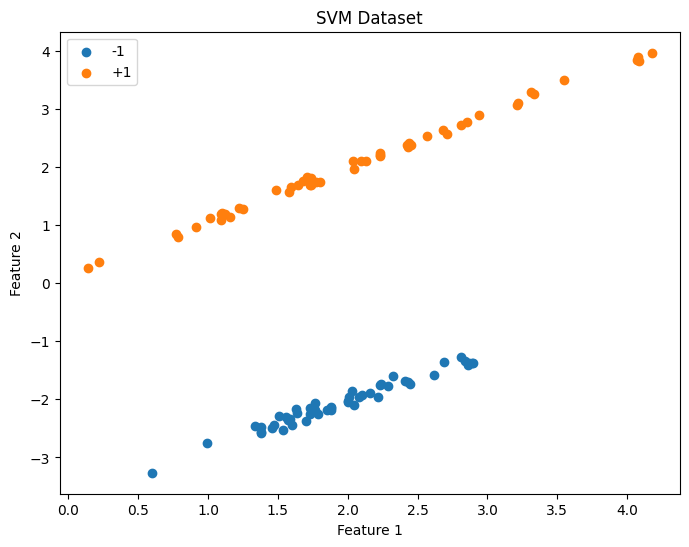

Scratch SVM Accuracy: 1.0


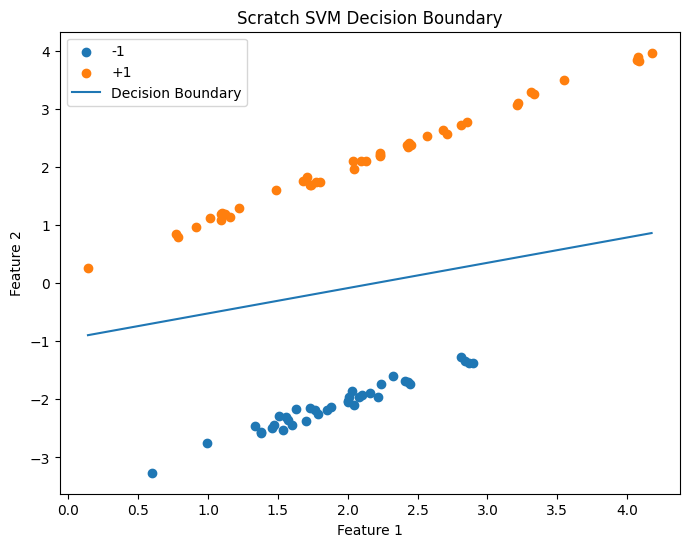


Linear SVM Accuracy: 1.0

Number of support vectors: 3

Support vector indices:
[34  9 73]

Support vectors:
[[ 2.32272135 -1.59340317]
 [ 0.78801347  0.79334842]
 [ 0.14147759  0.26526486]]
Linear Kernel Accuracy: 0.43
RBF Kernel Accuracy: 1.0


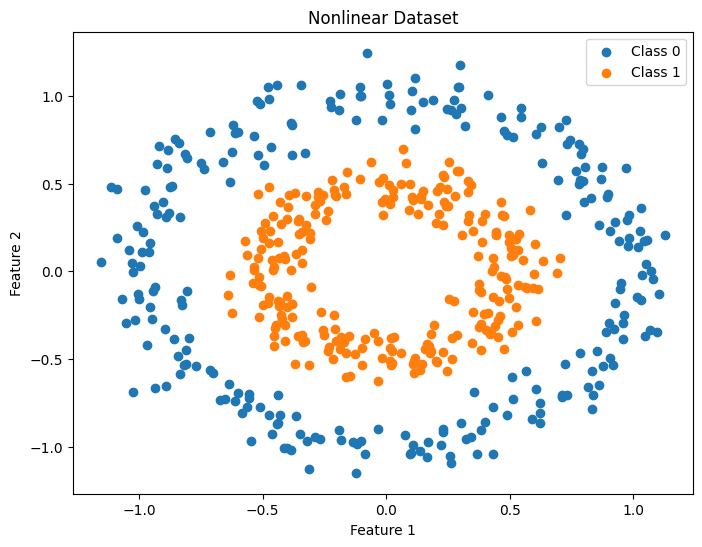

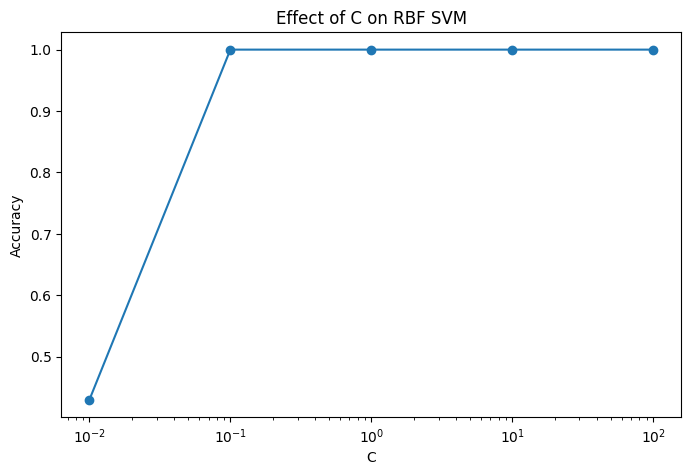

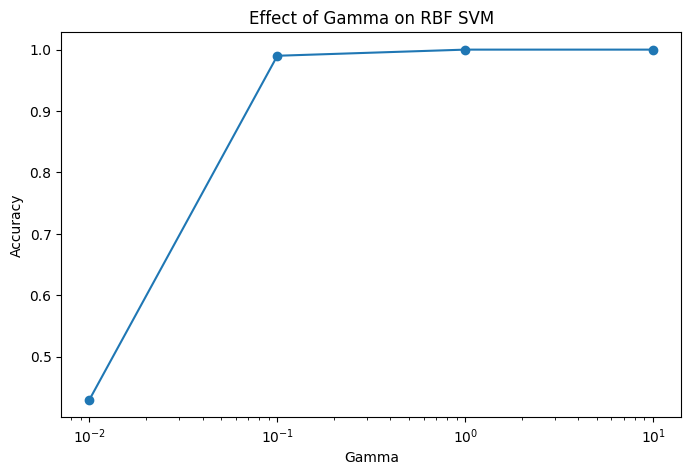


Scaled SVM Accuracy: 1.0


In [1]:
# ============================================================
# SVM — SUPPORT VECTOR MACHINE 🔴
# ============================================================
#
# DEEP LEARNING LEVEL:
#   🔴 Understand math + internal working
#   🔴 Simple implementation from scratch
#   🔴 sklearn implementation
#
# Main topics:
#
#   1. Why SVM?
#   2. Intuition
#   3. Margin
#   4. Hyperplane
#   5. Support Vectors
#   6. Hinge Loss
#   7. Soft Margin
#   8. C parameter
#   9. Kernel Trick
#  10. Linear / Polynomial / RBF kernels
#  11. Scratch Linear SVM
#  12. sklearn SVM
#  13. Important parameters
#  14. Experiments
#  15. Interview questions
#  16. 30-second explanation
#  17. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.svm import SVC


# ============================================================
# 2. WHY SVM?
# ============================================================
#
# Suppose we have two classes:
#
#        ● ● ●
#       ● ● ●
#
#
#                 ○ ○ ○
#                ○ ○ ○
#
#
# Many lines can separate them.
#
# SVM tries to find a separating boundary with the
# MAXIMUM MARGIN.
#
#
#              ● ●
#             ● ●
#
#               | margin
#               |
#       --------|--------  Decision Boundary
#               |
#               |
#              ○ ○
#             ○ ○
#
#
# SVM tries to keep the boundary as far as possible from
# the closest training examples of both classes.
#
# ============================================================


# ============================================================
# 3. BASIC SVM INTUITION
# ============================================================
#
# Decision boundary:
#
#       w.x + b = 0
#
#
# For 2D:
#
#       w1*x1 + w2*x2 + b = 0
#
#
# Prediction:
#
#       w.x + b > 0  -> Class +1
#
#       w.x + b < 0  -> Class -1
#
#
# SVM wants:
#
#       correct classification
#              +
#       maximum margin
#
# ============================================================


# ============================================================
# 4. WHAT IS A HYPERPLANE?
# ============================================================
#
# In 2 dimensions:
#
#       w1*x1 + w2*x2 + b = 0
#
# is a LINE.
#
#
# In 3 dimensions:
#
#       w1*x1 + w2*x2 + w3*x3 + b = 0
#
# is a PLANE.
#
#
# In higher dimensions:
#
#       HYPERPLANE
#
#
# General equation:
#
#       w.x + b = 0
#
# ============================================================


# ============================================================
# 5. SVM MARGIN ⭐⭐⭐
# ============================================================
#
# For a normalized SVM:
#
#       w.x + b = +1
#
# and
#
#       w.x + b = -1
#
# are the two margin boundaries.
#
#
# Decision boundary:
#
#       w.x + b = 0
#
#
# The distance between the two margin boundaries is:
#
#                    2
#                  ----
#                   ||w||
#
#
# Therefore:
#
# MAXIMUM MARGIN
#
# means:
#
#       minimize ||w||
#
# ============================================================


# ============================================================
# 6. SUPPORT VECTORS ⭐⭐⭐
# ============================================================
#
# The closest training points to the decision boundary are
# called SUPPORT VECTORS.
#
#
# Example:
#
#
#       ● ● ●
#          ●
#          |
#          |   ← Support Vector
#       ---●----------------
#          |
#          |   ← Support Vector
#          ○
#       ○ ○ ○
#
#
# These points determine the position of the boundary/margin.
#
#
# Important:
#
# Not every training point is equally important.
#
# Support vectors are the critical points.
#
# ============================================================


# ============================================================
# 7. HARD-MARGIN SVM
# ============================================================
#
# If the data is perfectly separable:
#
#       y_i * (w.x_i + b) >= 1
#
# for every training point.
#
#
# Optimization:
#
#       minimize:
#
#             1/2 ||w||²
#
# subject to:
#
#       y_i(w.x_i + b) >= 1
#
#
# Why minimize ||w||²?
#
# Because:
#
#       margin = 2 / ||w||
#
# Therefore:
#
# smaller ||w||
#       ↓
# larger margin
#
# ============================================================


# ============================================================
# 8. SOFT-MARGIN SVM ⭐⭐⭐
# ============================================================
#
# Real-world data is usually NOT perfectly separable.
#
# Some points may:
#
#   - be inside the margin
#   - be misclassified
#
#
# SVM introduces slack variables and allows violations.
#
# The practical objective becomes:
#
#       minimize:
#
#       1/2 ||w||² + C * sum(slack)
#
#
# C controls the trade-off between:
#
#       Large margin
#           vs
#       Classification errors
#
# ============================================================


# ============================================================
# 9. WHAT IS C? ⭐⭐⭐
# ============================================================
#
# C = penalty for classification errors / margin violations.
#
#
# SMALL C:
#
#       errors are less expensive
#              ↓
#       wider margin
#              ↓
#       more tolerance for mistakes
#              ↓
#       stronger regularization
#
#
# LARGE C:
#
#       errors are expensive
#              ↓
#       model tries harder to classify training points
#              ↓
#       narrower margin
#              ↓
#       can overfit
#
#
# Easy memory:
#
#       C ↑
#       ↓
#       less tolerance for errors
#
#
#       C ↓
#       ↓
#       more tolerance for errors
#
# ============================================================


# ============================================================
# 10. HINGE LOSS ⭐⭐⭐
# ============================================================
#
# SVM commonly uses Hinge Loss.
#
#
# Loss:
#
#       L = max(0, 1 - y*f(x))
#
# where:
#
#       f(x) = w.x + b
#
#
# If:
#
#       y*f(x) >= 1
#
# then:
#
#       Loss = 0
#
#
# If:
#
#       y*f(x) < 1
#
# then:
#
#       Loss > 0
#
#
# Example:
#
# y = +1
# prediction score = 2
#
#       y*f(x) = 2
#
#       loss = max(0, 1-2)
#            = 0
#
#
# Example:
#
# y = +1
# prediction score = 0.5
#
#       loss = max(0, 1-0.5)
#            = 0.5
#
# ============================================================


# ============================================================
# 11. SVM OBJECTIVE FUNCTION
# ============================================================
#
# A simplified soft-margin objective:
#
#
#       1/2 ||w||²
#       +
#       C * sum(Hinge Loss)
#
#
# First part:
#
#       1/2 ||w||²
#
# controls model complexity / margin.
#
#
# Second part:
#
#       C * Hinge Loss
#
# penalizes classification mistakes and margin violations.
#
#
# So SVM balances:
#
#       LARGE MARGIN
#             +
#       LOW CLASSIFICATION ERROR
#
# ============================================================


# ============================================================
# 12. CREATE SIMPLE DATA
# ============================================================

X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=42
)

# Convert labels:
#
# sklearn gives:
#       0, 1
#
# SVM math is easier with:
#       -1, +1

y_svm = np.where(y == 0, -1, 1)

print("First 10 labels:")
print(y_svm[:10])


# ============================================================
# 13. VISUALIZE DATA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y_svm == -1, 0],
    X[y_svm == -1, 1],
    label="-1"
)

plt.scatter(
    X[y_svm == 1, 0],
    X[y_svm == 1, 1],
    label="+1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Dataset")

plt.legend()
plt.show()


# ============================================================
# 14. SIMPLE SVM FROM SCRATCH
# ============================================================
#
# IMPORTANT:
#
# This is an EDUCATIONAL simplified linear SVM.
#
# It uses gradient descent on:
#
#       1/2 ||w||² + C * Hinge Loss
#
# This is NOT how sklearn's highly optimized SVC solver
# is implemented internally.
#
# The purpose is to understand the core SVM idea.
#
# ============================================================


class SimpleSVM:

    def __init__(
        self,
        learning_rate=0.001,
        C=1.0,
        epochs=1000
    ):
        self.learning_rate = learning_rate
        self.C = C
        self.epochs = epochs

        self.w = None
        self.b = None


    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.w = np.zeros(n_features)
        self.b = 0.0

        # Gradient descent
        for _ in range(self.epochs):

            for i in range(n_samples):

                # Calculate decision score
                score = np.dot(X[i], self.w) + self.b

                # Check hinge-loss condition
                if y[i] * score >= 1:

                    # Only regularization contributes
                    self.w -= (
                        self.learning_rate * self.w
                    )

                else:

                    # Gradient of:
                    #
                    # 1/2 ||w||² + C * hinge_loss
                    #
                    self.w -= self.learning_rate * (
                        self.w
                        - self.C * y[i] * X[i]
                    )

                    self.b -= (
                        self.learning_rate
                        * (-self.C * y[i])
                    )

        return self


    def decision_function(self, X):

        return np.dot(X, self.w) + self.b


    def predict(self, X):

        scores = self.decision_function(X)

        return np.where(scores >= 0, 1, -1)


# ============================================================
# 15. TRAIN SCRATCH SVM
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_svm,
    test_size=0.2,
    random_state=42
)

scratch_model = SimpleSVM(
    learning_rate=0.001,
    C=1.0,
    epochs=1000
)

scratch_model.fit(X_train, y_train)

scratch_pred = scratch_model.predict(X_test)

print(
    "Scratch SVM Accuracy:",
    accuracy_score(y_test, scratch_pred)
)


# ============================================================
# 16. UNDERSTAND THE SCRATCH IMPLEMENTATION
# ============================================================
#
# For every training point:
#
#       score = w.x + b
#
#             ↓
#
#       y * score
#
#             ↓
#
#       Is it >= 1 ?
#
#       /           \
#     YES           NO
#      |             |
#      ↓             ↓
# No hinge       Hinge loss
# loss           exists
#      |             |
#      ↓             ↓
# Only           Update w and b
# regularization
#
#
# Repeat for all samples.
#
# ============================================================


# ============================================================
# 17. VISUALIZE SCRATCH DECISION BOUNDARY
# ============================================================

def plot_decision_boundary(model, X, y):

    plt.figure(figsize=(8, 6))

    # Plot points
    plt.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        label="-1"
    )

    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        label="+1"
    )

    # Create x-axis values
    x_values = np.linspace(
        X[:, 0].min(),
        X[:, 0].max(),
        100
    )

    # w1*x1 + w2*x2 + b = 0
    #
    # Therefore:
    #
    # x2 = -(w1*x1 + b) / w2

    y_values = -(
        model.w[0] * x_values
        + model.b
    ) / model.w[1]

    plt.plot(
        x_values,
        y_values,
        label="Decision Boundary"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Scratch SVM Decision Boundary")

    plt.legend()
    plt.show()


plot_decision_boundary(
    scratch_model,
    X_train,
    y_train
)


# ============================================================
# 18. SKLEARN SVM — LINEAR KERNEL
# ============================================================
#
# In real projects/interviews, use sklearn.
#
# SVC = Support Vector Classifier.
#
# ============================================================

linear_svm = SVC(
    kernel="linear",
    C=1.0
)

linear_svm.fit(
    X_train,
    y_train
)

pred = linear_svm.predict(X_test)

print(
    "\nLinear SVM Accuracy:",
    accuracy_score(y_test, pred)
)


# ============================================================
# 19. SUPPORT VECTORS
# ============================================================
#
# sklearn gives us the support vectors directly.
# ============================================================

print(
    "\nNumber of support vectors:",
    len(linear_svm.support_)
)

print(
    "\nSupport vector indices:"
)

print(linear_svm.support_)

print(
    "\nSupport vectors:"
)

print(linear_svm.support_vectors_)


# ============================================================
# 20. WHY DO WE NEED KERNELS?
# ============================================================
#
# Linear SVM works when data can be separated reasonably
# well using a straight line / hyperplane.
#
# But consider:
#
#
#              ○ ○ ○
#           ○         ○
#          ○    ●●     ○
#          ○   ●●●     ○
#           ○         ○
#              ○ ○ ○
#
#
# A straight line cannot separate the classes properly.
#
# We need a nonlinear decision boundary.
#
# This is where KERNELS help.
#
# ============================================================


# ============================================================
# 21. KERNEL TRICK ⭐⭐⭐
# ============================================================
#
# The idea:
#
# Transform data into a higher-dimensional feature space
# where it may become linearly separable.
#
#
# Original space:
#
#       x1, x2
#
#             ↓
#
#      Feature Transformation
#
#             ↓
#
#       x1, x2, x1², x2², x1*x2 ...
#
#             ↓
#
#       Linear separation
#
#
# But explicitly creating all those features can be expensive.
#
# Kernel Trick allows us to calculate similarities in the
# higher-dimensional space without explicitly creating
# all those features.
#
# ============================================================


# ============================================================
# 22. KERNEL FUNCTION
# ============================================================
#
# A kernel calculates similarity between two points.
#
# General idea:
#
#       K(x_i, x_j)
#
#
# Instead of explicitly calculating:
#
#       phi(x_i) . phi(x_j)
#
# we calculate:
#
#       K(x_i, x_j)
#
#
# This is the KERNEL TRICK.
#
# ============================================================


# ============================================================
# 23. IMPORTANT KERNELS
# ============================================================
#
#
# 1. linear
#
#       K(x,z) = x.z
#
#
# 2. polynomial
#
#       K(x,z) = (gamma*x.z + coef0)^degree
#
#
# 3. RBF / Gaussian ⭐⭐⭐
#
#       K(x,z) =
#       exp(-gamma * ||x-z||²)
#
#
# RBF is very commonly used for nonlinear SVM.
#
# ============================================================


# ============================================================
# 24. RBF KERNEL INTUITION
# ============================================================
#
# RBF measures how close two points are.
#
#
# If points are close:
#
#       distance small
#             ↓
#       similarity high
#
#
# If points are far:
#
#       distance large
#             ↓
#       similarity low
#
#
# Formula:
#
#       K(x,z) =
#       exp(-gamma * ||x-z||²)
#
# ============================================================


# ============================================================
# 25. NONLINEAR DATASET
# ============================================================

X_circle, y_circle = make_circles(
    n_samples=500,
    factor=0.5,
    noise=0.08,
    random_state=42
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circle,
    y_circle,
    test_size=0.2,
    random_state=42
)


# ============================================================
# 26. LINEAR SVM ON NONLINEAR DATA
# ============================================================

linear_model = SVC(
    kernel="linear",
    C=1.0
)

linear_model.fit(
    X_train_c,
    y_train_c
)

linear_pred = linear_model.predict(X_test_c)

print(
    "Linear Kernel Accuracy:",
    accuracy_score(y_test_c, linear_pred)
)


# ============================================================
# 27. RBF SVM ON NONLINEAR DATA
# ============================================================

rbf_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

rbf_model.fit(
    X_train_c,
    y_train_c
)

rbf_pred = rbf_model.predict(X_test_c)

print(
    "RBF Kernel Accuracy:",
    accuracy_score(y_test_c, rbf_pred)
)


# ============================================================
# 28. VISUALIZE NONLINEAR DATA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X_circle[y_circle == 0, 0],
    X_circle[y_circle == 0, 1],
    label="Class 0"
)

plt.scatter(
    X_circle[y_circle == 1, 0],
    X_circle[y_circle == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinear Dataset")

plt.legend()
plt.show()


# ============================================================
# 29. IMPORTANT PARAMETERS — SVC
# ============================================================

# ------------------------------------------------------------
# C ⭐⭐⭐
# ------------------------------------------------------------
#
# Controls penalty for errors.
#
# Small C:
#   wider margin
#   more tolerance
#   stronger regularization
#
# Large C:
#   tries harder to classify training examples
#   narrower margin
#   possible overfitting
#
#
# ------------------------------------------------------------
# kernel ⭐⭐⭐
# ------------------------------------------------------------
#
# Defines the similarity function.
#
# Options:
#
# "linear"
# "poly"
# "rbf"
# "sigmoid"
#
#
# ------------------------------------------------------------
# gamma ⭐⭐⭐
# ------------------------------------------------------------
#
# Mainly important for:
#
#   rbf
#   poly
#   sigmoid
#
#
# For RBF:
#
#       K(x,z) =
#       exp(-gamma * ||x-z||²)
#
#
# Small gamma:
#
#       broader influence
#       smoother decision boundary
#
#
# Large gamma:
#
#       very local influence
#       more complex boundary
#       possible overfitting
#
#
# ------------------------------------------------------------
# degree
# ------------------------------------------------------------
#
# Degree of polynomial kernel.
#
# Only relevant for:
#
#       kernel="poly"
#
#
# ------------------------------------------------------------
# coef0
# ------------------------------------------------------------
#
# Independent term in polynomial/sigmoid kernels.
#
#
# ------------------------------------------------------------
# class_weight
# ------------------------------------------------------------
#
# Useful for imbalanced classification.
#
# Example:
#
#       class_weight="balanced"
#
#
# ------------------------------------------------------------
# probability
# ------------------------------------------------------------
#
# If:
#
#       probability=True
#
# sklearn enables probability estimates.
#
# This adds computational overhead.
#
#
# ------------------------------------------------------------
# max_iter
# ------------------------------------------------------------
#
# Maximum number of iterations.
#
# -1 means no limit.
#
# ============================================================


# ============================================================
# 30. EXPERIMENT — DIFFERENT C VALUES
# ============================================================

C_values = [0.01, 0.1, 1, 10, 100]

scores = []

for C in C_values:

    model = SVC(
        kernel="rbf",
        C=C,
        gamma="scale"
    )

    model.fit(
        X_train_c,
        y_train_c
    )

    pred = model.predict(X_test_c)

    scores.append(
        accuracy_score(y_test_c, pred)
    )


plt.figure(figsize=(8, 5))

plt.plot(
    C_values,
    scores,
    marker="o"
)

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Effect of C on RBF SVM")

plt.show()


# ============================================================
# 31. EXPERIMENT — DIFFERENT GAMMA VALUES
# ============================================================

gamma_values = [0.01, 0.1, 1, 10]

scores = []

for gamma in gamma_values:

    model = SVC(
        kernel="rbf",
        C=1.0,
        gamma=gamma
    )

    model.fit(
        X_train_c,
        y_train_c
    )

    pred = model.predict(X_test_c)

    scores.append(
        accuracy_score(y_test_c, pred)
    )


plt.figure(figsize=(8, 5))

plt.plot(
    gamma_values,
    scores,
    marker="o"
)

plt.xscale("log")

plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.title("Effect of Gamma on RBF SVM")

plt.show()


# ============================================================
# 32. C vs GAMMA ⭐⭐⭐
# ============================================================
#
# VERY IMPORTANT INTERVIEW CONCEPT.
#
#
# C:
#
# Controls how much we penalize training errors.
#
#
# gamma:
#
# Controls how far the influence of a training point extends
# in RBF kernel.
#
#
# Small gamma:
#
#       broad influence
#            ↓
#       smoother boundary
#
#
# Large gamma:
#
#       local influence
#            ↓
#       complex boundary
#
#
# Small C:
#
#       tolerate more errors
#            ↓
#       wider margin
#
#
# Large C:
#
#       tolerate fewer errors
#            ↓
#       narrower margin
#
# ============================================================


# ============================================================
# 33. SVM vs LOGISTIC REGRESSION
# ============================================================
#
# Both can produce linear decision boundaries.
#
#
# Logistic Regression:
#
#       focuses on probability/log-loss
#
#
# SVM:
#
#       focuses on maximum margin
#       + hinge loss
#
#
# Logistic Regression:
#
#       naturally provides probabilities
#
#
# SVM:
#
#       focuses on boundary/margin
#       probability requires additional processing
#
#
# ============================================================


# ============================================================
# 34. SVM vs DECISION TREE
# ============================================================
#
# SVM:
#
#       Hyperplane
#       Margin
#       Support vectors
#       Kernels
#
#
# Decision Tree:
#
#       Feature splits
#       Thresholds
#       Recursive partitioning
#
#
# ============================================================


# ============================================================
# 35. ADVANTAGES OF SVM
# ============================================================
#
# 1. Effective in high-dimensional spaces
#
# 2. Works well when classes have a clear margin
#
# 3. Kernel trick allows nonlinear boundaries
#
# 4. Only support vectors are critical to the final
#    decision boundary
#
# ============================================================


# ============================================================
# 36. DISADVANTAGES OF SVM
# ============================================================
#
# 1. Can become expensive on very large datasets
#
# 2. Sensitive to feature scaling
#
# 3. Kernel and hyperparameter selection can be important
#
# 4. Less interpretable than a simple decision tree
#
# ============================================================


# ============================================================
# 37. FEATURE SCALING ⭐⭐⭐
# ============================================================
#
# SVM is sensitive to feature scale because it uses distances
# and dot products.
#
# Example:
#
# Feature 1:
#       age = 20 - 60
#
# Feature 2:
#       salary = 20,000 - 2,00,000
#
# Salary can dominate the distance calculation.
#
#
# Therefore scaling is usually important for SVM.
#
# Example:
#
# StandardScaler
#       ↓
# mean = 0
# std = 1
#
#
# In real projects:
#
# StandardScaler
#       ↓
# SVM
#
# ============================================================


# ============================================================
# 38. SVM WITH STANDARD SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scaled_svm = Pipeline([
    ("scaler", StandardScaler()),

    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

scaled_svm.fit(
    X_train_c,
    y_train_c
)

scaled_pred = scaled_svm.predict(
    X_test_c
)

print(
    "\nScaled SVM Accuracy:",
    accuracy_score(
        y_test_c,
        scaled_pred
    )
)


# ============================================================
# 39. IMPORTANT INTERVIEW QUESTIONS
# ============================================================
#
#
# Q1. What is SVM?
#
# Answer:
#
# SVM is a supervised learning algorithm that finds a
# decision boundary with maximum margin between classes.
#
#
# ------------------------------------------------------------
#
# Q2. What is the margin?
#
# Answer:
#
# Margin is the distance between the decision boundary and
# the closest training points from the classes.
#
#
# ------------------------------------------------------------
#
# Q3. What are support vectors?
#
# Answer:
#
# Support vectors are the training points closest to the
# decision boundary and they determine the position of the
# optimal margin/boundary.
#
#
# ------------------------------------------------------------
#
# Q4. Why minimize ||w||²?
#
# Answer:
#
# Because the SVM margin is:
#
#       2 / ||w||
#
# Minimizing ||w||² therefore maximizes the margin.
#
#
# ------------------------------------------------------------
#
# Q5. What is hinge loss?
#
# Answer:
#
#       max(0, 1 - y*f(x))
#
# It penalizes points that are misclassified or lie inside
# the desired margin.
#
#
# ------------------------------------------------------------
#
# Q6. What is C?
#
# Answer:
#
# C controls the trade-off between maximizing the margin
# and penalizing classification errors.
#
#
# ------------------------------------------------------------
#
# Q7. What is the kernel trick?
#
# Answer:
#
# It allows SVM to work in a higher-dimensional feature space
# by calculating similarities using a kernel function without
# explicitly creating all transformed features.
#
#
# ------------------------------------------------------------
#
# Q8. What is RBF kernel?
#
# Answer:
#
# RBF is a nonlinear kernel based on the distance between
# points:
#
#       K(x,z) =
#       exp(-gamma * ||x-z||²)
#
#
# ------------------------------------------------------------
#
# Q9. What does gamma control?
#
# Answer:
#
# Gamma controls how far the influence of a training point
# extends in kernels such as RBF.
#
#
# Small gamma:
#   smoother boundary
#
# Large gamma:
#   more complex/local boundary
#
#
# ------------------------------------------------------------
#
# Q10. Why scale features before SVM?
#
# Answer:
#
# SVM depends on distances and dot products, so features
# with larger numerical scales can dominate the model.
#
#
# ------------------------------------------------------------
#
# Q11. SVM vs Logistic Regression?
#
# Answer:
#
# Logistic Regression optimizes log loss and naturally
# models probabilities, while SVM focuses on maximizing the
# margin using hinge loss.
#
#
# ============================================================


# ============================================================
# 40. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# SVM is a supervised learning algorithm that tries to find
# the hyperplane with the maximum margin between classes.
#
# The closest points to the boundary are called support
# vectors and they determine the margin.
#
# For non-linearly separable data, SVM can use kernels such
# as RBF to implicitly map the data into a higher-dimensional
# space.
#
# The important parameters are C, which controls the penalty
# for margin violations, and gamma, which controls the
# influence of individual points for kernels such as RBF.
#
# ============================================================


# ============================================================
# 41. FINAL MEMORY CHEATSHEET
# ============================================================
#
# SVM =
#
# Hyperplane
#     +
# Maximum Margin
#     +
# Support Vectors
#     +
# Hinge Loss
#     +
# Soft Margin
#     +
# Kernel Trick
#
#
# MUST REMEMBER:
#
# 1. Decision boundary:
#
#       w.x + b = 0
#
#
# 2. Margin:
#
#       2 / ||w||
#
#
# 3. Support vectors:
#
#       Closest points to boundary
#
#
# 4. Hinge Loss:
#
#       max(0, 1 - y*f(x))
#
#
# 5. Objective:
#
#       1/2 ||w||²
#       +
#       C * Hinge Loss
#
#
# 6. C:
#
#       Error penalty / margin trade-off
#
#
# 7. Kernel:
#
#       Allows nonlinear boundaries
#
#
# 8. RBF:
#
#       exp(-gamma * distance²)
#
#
# 9. Gamma:
#
#       Controls locality/influence
#
#
# 10. Feature scaling is important.
#
# ============================================================


# ============================================================
# 42. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                         SVM
#                          │
#                          ▼
#                Find Decision Boundary
#                          │
#                          ▼
#                     Hyperplane
#                          │
#                    w.x + b = 0
#                          │
#             ┌────────────┴────────────┐
#             │                         │
#             ▼                         ▼
#       Linearly separable        Nonlinear data
#             │                         │
#             ▼                         ▼
#        Linear SVM                Kernel SVM
#                                       │
#                    ┌──────────────────┼──────────────────┐
#                    │                  │                  │
#                    ▼                  ▼                  ▼
#                 Linear              Poly               RBF
#                                                          │
#                                                          ▼
#                                               Kernel Trick
#                                                          │
#                                                          ▼
#                                          Higher-dimensional space
#                                                          │
#                                                          ▼
#                                               Find hyperplane
#
#
# ============================================================
#
# DETAILED SVM TRAINING FLOW:
#
#
#                  Training Data
#                       │
#                       ▼
#                 Feature Scaling
#                       │
#                       ▼
#                Choose Kernel
#                       │
#                       ▼
#            Calculate decision function
#                       │
#                       ▼
#                 Calculate Margin
#                       │
#                       ▼
#                Calculate Hinge Loss
#                       │
#                       ▼
#              Optimize Objective
#                       │
#             ┌─────────┴─────────┐
#             │                   │
#             ▼                   ▼
#       Large margin        Low classification
#                              error
#             │                   │
#             └─────────┬─────────┘
#                       ▼
#                Find Support Vectors
#                       │
#                       ▼
#              Final Decision Boundary
#                       │
#                       ▼
#                    Prediction
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
# Data
#   ↓
# Find the widest possible separating boundary
#   ↓
# Allow some mistakes using C
#   ↓
# Only critical points = Support Vectors
#   ↓
# Use Kernel Trick when boundary is nonlinear
#
# ============================================================